# НС для классификации 3 классов на квадрате [0,1]x[0,1]

Задача: Реализовать НС для решения задачи классификации на 3 класса:
- класс 1: внутри окружности (0.2, 0.2), r=0.15
- класс 2: внутри окружности (0.7, 0.7), r=0.2
- класс 3: все остальное

Критерии выполнения:
1) Попробовать разное количество внутренних слоев, сравнить точность
2) Сравнить графики сходимости для разных оптимизаторов

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


## Генерация датасета

Накладываем равномерно точки на квадрат [0,1]x[0,1]
Проверяем, попала ли точка в круг 1 (класс 0) или в круг 2 (класс 1)

In [3]:
def make_dataset(n_points, seed=123):
    rng = np.random.default_rng(seed)
    xy = rng.uniform(0.0, 1.0, size=(n_points, 2)).astype(np.float32)

    x = xy[:, 0]
    y = xy[:, 1]

    
    c1x, c1y, r1 = 0.2, 0.2, 0.15
    d1 = (x - c1x) ** 2 + (y - c1y) ** 2
    inside1 = d1 <= r1 ** 2


    c2x, c2y, r2 = 0.7, 0.7, 0.2
    d2 = (x - c2x) ** 2 + (y - c2y) ** 2
    inside2 = d2 <= r2 ** 2

    labels = np.full((n_points,), 2, dtype=np.int64)
    labels[inside1] = 0
    labels[inside2] = 1

    X = torch.tensor(xy, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.long)
    return X, y

X_train, y_train = make_dataset(30000, seed=1)
X_test, y_test = make_dataset(6000, seed=2)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([30000, 2]),
 torch.Size([30000]),
 torch.Size([6000, 2]),
 torch.Size([6000]))

## Визуализируем

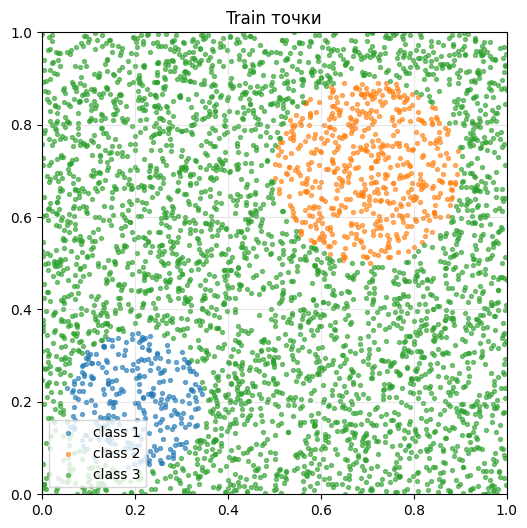

In [4]:
def plot_points(X, y, title, n_show=4000):
    idx = torch.randperm(X.size(0))[:n_show]
    Xs = X[idx].cpu().numpy()
    ys = y[idx].cpu().numpy()

    plt.figure(figsize=(6, 6))
    for cls in [0, 1, 2]:
        mask = ys == cls
        plt.scatter(Xs[mask, 0], Xs[mask, 1], s=8, alpha=0.6, label=f"class {cls+1}")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.legend()
    plt.show()

plot_points(X_train, y_train, "Train точки")


Разобьем данные на пакеты с помощью класса `DataLoader`

In [5]:
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, drop_last=False)

## Модель

Заготовим класс `MLP` под многослойный персептрон. В этот класс можно передавать список размеров скрытых слоев, чтобы пробовать один скрытый слой, два, три и так далее. Внутри класса в цикле я добавляю слои `Linear` и `ReLU`, а затем в конце добавляю еще один слой на 3 выхода, потому что у нас 3 класса. 

In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()

        layers = []
        in_dim = 2

        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h

        layers.append(nn.Linear(in_dim, 3))  
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


m = MLP([64, 64])
out = m(torch.randn(5, 2))
out.shape


torch.Size([5, 3])

## Тренировка и оценка

Функцией `evaluate` будем считать *loss* и сколько предсказаний совпало с ответами. 
Функция `make_optimizer` для удобства сделал, чтобы не прописывать вручную каждый раз (Привычка от принципа DRY изложенный в гайд буке по Python Марка Лутца)
Функция `train_model` по названию говорит сама за себя: собирает модель, выбирает оптимизатор, настраивает критерий ошибки и уже в цикле по эпохам проводит тренировку, параллельно считая loss, acc. Сохраняем всю историю тренировки в словаре.

In [7]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        pred = torch.argmax(logits, dim=1)
        total_correct += (pred == yb).sum().item()
        total += xb.size(0)

    avg_loss = total_loss / total
    acc = total_correct / total
    return avg_loss, acc


def make_optimizer(name, params, lr):
    name = name.lower().strip()

    if name == "adam":
        return torch.optim.Adam(params, lr=lr)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr)

    raise ValueError(f"Unknown optimizer: {name}")


def train_model(hidden_sizes, optimizer_name, lr, epochs, train_loader, test_loader, device, seed=123):
    set_seed(seed)

    model = MLP(hidden_sizes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(optimizer_name, model.parameters(), lr)

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for ep in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            pred = torch.argmax(logits, dim=1)
            running_correct += (pred == yb).sum().item()
            running_total += xb.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["epoch"].append(ep)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

    return model, history


In [8]:
def plot_history(histories, title_prefix=""):
    # histories: dict[name] = history
    plt.figure(figsize=(8, 5))
    for name, h in histories.items():
        plt.plot(h["epoch"], h["test_loss"], label=f"{name}")
    plt.grid(True, alpha=0.3)
    plt.xlabel("epoch")
    plt.ylabel("test_loss")
    plt.title(f"{title_prefix} test_loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    for name, h in histories.items():
        plt.plot(h["epoch"], h["test_acc"], label=f"{name}")
    plt.grid(True, alpha=0.3)
    plt.xlabel("epoch")
    plt.ylabel("test_acc")
    plt.title(f"{title_prefix} test_acc")
    plt.legend()
    plt.show()


## Эксперимент 1: разное число скрытых слоев

Фиксируем оптимизатор (Adam) и ширину слоев и будем меняем глубину.  

Я возьму:
1 скрытый слой: [64]
2 скрытых слоя: [64, 64]
3 скрытых слоя: [64, 64, 64]

Здесь я пробую `device="cpu"`, а далее испозую `cuda`. Спойлер: в моём случае `cpu` был быстрее


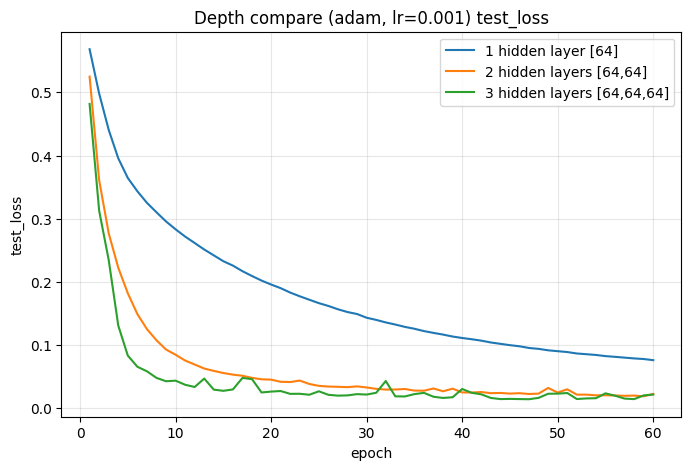

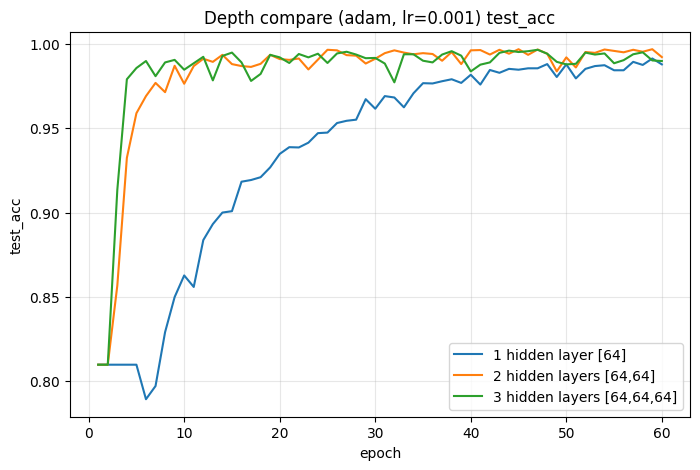

{'1 hidden layer [64]': (0.988, 0.07600656553109487),
 '2 hidden layers [64,64]': (0.9923333333333333, 0.02249886703491211),
 '3 hidden layers [64,64,64]': (0.99, 0.021625482718149822)}

In [15]:
depth_configs = {
    "1 hidden layer [64]": [64],
    "2 hidden layers [64,64]": [64, 64],
    "3 hidden layers [64,64,64]": [64, 64, 64],
}

depth_histories = {}
depth_final = {}

epochs = 60
optimizer_name = "adam"
lr = 1e-3

for name, hs in depth_configs.items():
    model, hist = train_model(
        hidden_sizes=hs,
        optimizer_name=optimizer_name,
        lr=lr,
        epochs=epochs,
        train_loader=train_loader,
        test_loader=test_loader,
        device="cpu",
        seed=100
    )
    depth_histories[name] = hist
    depth_final[name] = (hist["test_acc"][-1], hist["test_loss"][-1])

plot_history(depth_histories, title_prefix=f"Depth compare ({optimizer_name}, lr={lr})")

depth_final


In [16]:
import pandas as pd

df_depth = pd.DataFrame([
    {"model": k, "final_test_acc": v[0], "final_test_loss": v[1]}
    for k, v in depth_final.items()
]).sort_values("final_test_acc", ascending=False)

df_depth.reset_index(drop=True, inplace=True)
df_depth


,model,final_test_acc,final_test_loss
0,"2 hidden layers [64,64]",0.992333,0.022499
1,"3 hidden layers [64,64,64]",0.990000,0.021625
2,1 hidden layer [64],0.988000,0.076007


#### Выводы

В первом эксперименте видно, что глубина сети влияет на скорость и качество обучения. По графику test_loss и test_acc видно, что модель с одним скрытым слоем учится медленнее. Модель с двумя скрытыми слоями сходится намного быстрее. В таблице она лучше всех по точности. Модель с тремя скрытыми слоями на равне с двумя слоями учится быстро, но по точности оказалась хуже немного, что не сказать о её final_test_loss. ПОдводя итоги, один слой в этой задаче слабый, второй слой дает лучшую точность, а третий слой меньше ошибается.

## Эксперимент 2: сравнение оптимизаторов по сходимости

Теперь фиксируем архитектуру и меняем оптимизатор.

Я сравню:
1) SGD 
2) RMSprop
3) Adam

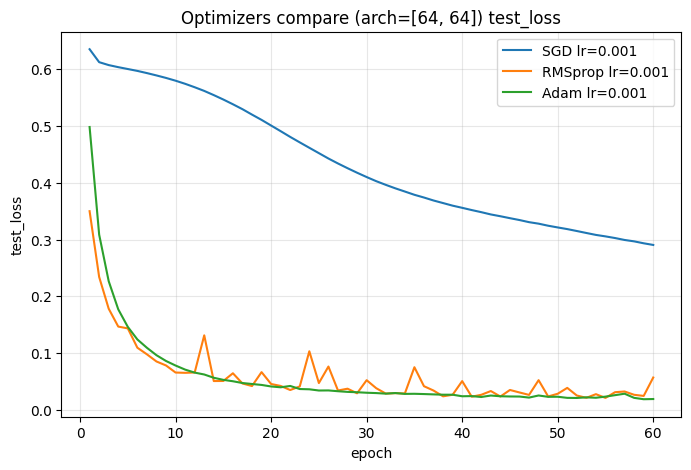

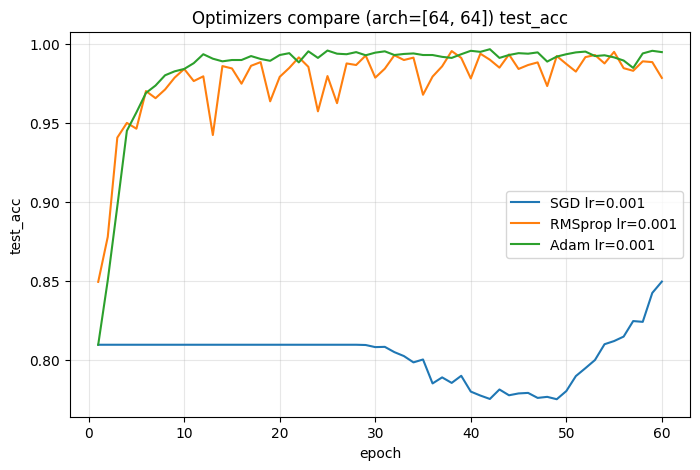

{'SGD lr=0.001': (0.8496666666666667, 0.29045144152641295),
 'RMSprop lr=0.001': (0.9786666666666667, 0.05726608375708262),
 'Adam lr=0.001': (0.995, 0.01945211960375309)}

In [17]:
opt_arch = [64, 64]
epochs = 60

optimizers = {
    "SGD lr=0.001": ("sgd", 1e-3),
    "RMSprop lr=0.001": ("rmsprop", 1e-3),
    "Adam lr=0.001": ("adam", 1e-3),
}

opt_histories = {}
opt_final = {}

for name, (opt_name, lr) in optimizers.items():
    model, hist = train_model(
        hidden_sizes=opt_arch,
        optimizer_name=opt_name,
        lr=lr,
        epochs=epochs,
        train_loader=train_loader,
        test_loader=test_loader,
        device="cuda",
        seed=200
    )
    opt_histories[name] = hist
    opt_final[name] = (hist["test_acc"][-1], hist["test_loss"][-1])

plot_history(opt_histories, title_prefix=f"Optimizers compare (arch={opt_arch})")

opt_final


### Итог по оптимизаторам таблицей

In [18]:
df_opt = pd.DataFrame([
    {"optimizer": k, "final_test_acc": v[0], "final_test_loss": v[1]}
    for k, v in opt_final.items()
]).sort_values("final_test_acc", ascending=False)

df_opt.reset_index(drop=True, inplace=True)
df_opt

,optimizer,final_test_acc,final_test_loss
0,Adam lr=0.001,0.995000,0.019452
1,RMSprop lr=0.001,0.978667,0.057266
2,SGD lr=0.001,0.849667,0.290451


#### Выводы:

Выбор оптимизатора сильно влияет на то, как быстро модель учится и насколько хорошо она в итоге работает. `Adam` оказался самым стабильным с лучшим acc и наименьшим loss. RMSprop тоже учится быстро, но имеет скачки. Из-за этого у него loss больше чем у `Adam`. `SGD` в этом случае вообще не подошёл. Под конец SGD начал подниматься, но остаётся всё на том же низком уровне по сравнению с первыми двумя оптимизаторами. 